In [1]:
cd ../..

/app


/usr/local/lib/python3.9/dist-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
%load_ext autoreload
%autoreload 2

import datajoint as db

%run run.py connect

2025-01-10 12:11:28,353::INFO::settings.py::Setting loglevel to INFO
2025-01-10 12:11:28,354::INFO::settings.py::Setting stores to {}
2025-01-10 12:11:28,355::INFO::settings.py::Setting database.misc.schema_prefix to 
2025-01-10 12:11:28,356::INFO::settings.py::Setting database.misc.create_tables to True
2025-01-10 12:11:28,357::INFO::settings.py::Setting enable_python_native_blobs to True
2025-01-10 12:11:28,358::INFO::settings.py::Setting database.host to 128.178.51.167:3309
2025-01-10 12:11:28,359::INFO::settings.py::Setting database.user to thomas
2025-01-10 12:11:28,360::INFO::settings.py::Setting database.password to thomas
2025-01-10 12:11:28,413::INFO::connection.py::Connected thomas@128.178.51.167:3309
2025-01-10 12:11:28,428::INFO::table.py::could not log event in table ~log


Connecting thomas@128.178.51.167:3309


2025-01-10 12:11:28,835::INFO::table.py::could not log event in table ~log
2025-01-10 12:11:28,835::INFO::table.py::could not log event in table ~log
2025-01-10 12:11:28,847::INFO::table.py::could not log event in table ~log
2025-01-10 12:11:28,847::INFO::table.py::could not log event in table ~log
2025-01-10 12:11:28,871::INFO::table.py::could not log event in table ~log
2025-01-10 12:11:28,871::INFO::table.py::could not log event in table ~log
2025-01-10 12:11:28,901::INFO::table.py::could not log event in table ~log
2025-01-10 12:11:28,901::INFO::table.py::could not log event in table ~log


In [3]:
from vr4mice.schema.base_analysis import DataFrame
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np
from vr4mice.analysis import plotting, regression
from base_schemas.schemas.exp import Session
from vr4mice.schema import base_analysis
from vr4mice.analysis.analysis import style
from vr4mice.analysis import analysis
from vr4mice.schema import dlc
from vr4mice.analysis import utils

from statsmodels.stats.anova import AnovaRM 
#import pingouin as pg
from scipy.stats import ttest_rel, ttest_ind
style()

save_fig_path =  "notebooks/Paper_figures/Figure_output/Figure4/"

In [4]:
multi_occluder = [{"dataset": "Nightingale_2024-08-15_1"},
                {"dataset": "Nightingale_2024-08-16_1"},
                {"dataset": "Nightingale_2024-08-21_1"},
                {"dataset": "Nightingale_2024-08-22_1"},
                {"dataset": "Lemming_2024-08-14_1"},
                {"dataset": "Lemming_2024-08-15_1"},
                {"dataset": "Lemming_2024-08-16_1"},
                {"dataset": "Lemming_2024-08-19_1"},
                {"dataset": "Jacana_2024-08-20_1"},
                {"dataset": "Jacana_2024-08-21_1"},
                {"dataset": "Jacana_2024-08-22_1"},
                {"dataset": "Kiwi_2024-08-19_1"},
                {"dataset": "Kiwi_2024-08-20_1"},
                {"dataset": "Kiwi_2024-08-21_1"},
                {'dataset': 'Pheasant_2024-08-23_1'},
                {'dataset': 'Pheasant_2024-08-26_1'},
                {'dataset': 'Pheasant_2024-08-27_2'},
                {'dataset': 'Pheasant_2024-08-28_1'},
                {'dataset': 'Oribi_2024-08-23_1'},
                {'dataset': 'Oribi_2024-08-26_1'},
                {'dataset': 'Oribi_2024-08-27_1'},
                {'dataset': 'Oribi_2024-08-28_1'},
                {'dataset': 'Oribi_2024-08-29_1'},
               ]

In [5]:
def get_all_in_list(data_set_list, training_stage):
    print(training_stage)
    big_df = []
    
    for d in data_set_list:
        split_d = d["dataset"].split("_")
        print(split_d)
        
        offline_kinematics_df = dlc.OfflineKinematics().get_data(key=d, columns = ["head_center_x", "head_center_y", "heading_dir", "head_angle"])
        df = base_analysis.DataFrame().get_data(key=d, 
                                                        columns=[
                                                            'dataset', 'trial', 'aperture',
                                                            'trial_right_choice', 'trial_left_choice',
                                                            'velocity', 'velocity_x', 'velocity_y',
                                                            "reward",
                                                            'norm_y', "iti", "x", "y",
                                                            'trial_init_x', 'trial_init_y',
                                                            "trial_tortuosity", "trial_duration"
        ])
        df["trial_rewarded"] = base_analysis.DataFrame().get_rewarded(key=d)
        
        df = df.join(offline_kinematics_df)
        
        df["mouse_name"] = split_d[0]
        df["date"] = split_d[1]
        df["attempt"] = split_d[2]
        df["training_stage"] = training_stage
        
        big_df.append(df)
    
    big_df =  pd.concat(big_df).reset_index()
    big_df ["session_increment"] = np.array(big_df.groupby("dataset").ngroup()+1)
    big_df = big_df.infer_objects()
    
    return(big_df.reset_index(drop=True))

In [6]:
big_df = pd.read_pickle("notebooks/Paper_figures/multi_occluder.pickle")

In [7]:
big_df = big_df [big_df.iti ==0.0]
big_df = big_df [big_df.trial_rewarded == 1.0]

In [8]:
big_df["norm_x"] = big_df.groupby(["dataset", "trial"], as_index=False)["x"].transform(
        lambda x: x - np.mean(x.iloc[:3])
    )


big_df["flip_one_side"] = big_df["trial_left_choice"].replace([0, 1], [1, -1])
columns = [
    "norm_y",
    "norm_x",
    "heading_dir",
    "head_angle",
    "trial_tortuosity",
    "trial_duration",
    "x",
    "y",
    "aperture",
    "velocity",
    "velocity_x",
    "velocity_y",
    "trial_rewarded",
    "norm_y",
    "flip_one_side",
]
j_shaped = analysis.get_jshaped_trials(big_df)

#j_shaped = j_shaped[j_shaped["trial_rewarded"]==1]

n_samples = 500
interpolated_j_shaped = utils.interpolate(
    j_shaped, n_points=n_samples, value_columns=["trial_left_choice"] + columns
)
interpolated_j_shaped["trial_step"] = interpolated_j_shaped.groupby(
    ["dataset", "trial"], as_index=False).trial.cumcount()


interpolated_j_shaped["trial_length"] = interpolated_j_shaped["trial_step"] / n_samples
interpolated_j_shaped["head_angle_sin"] = np.sin(np.deg2rad(interpolated_j_shaped.head_angle))
interpolated_j_shaped["head_angle_cos"] = np.cos(np.deg2rad(interpolated_j_shaped.head_angle))

interpolated_j_shaped["heading_dir_sin"] = np.sin(np.deg2rad(interpolated_j_shaped.heading_dir))
interpolated_j_shaped["heading_dir_cos"] = np.cos(np.deg2rad(interpolated_j_shaped.heading_dir))

interpolated_j_shaped["velocity_x_fliped"] = (
    interpolated_j_shaped["velocity_x"] * interpolated_j_shaped["flip_one_side"]
)

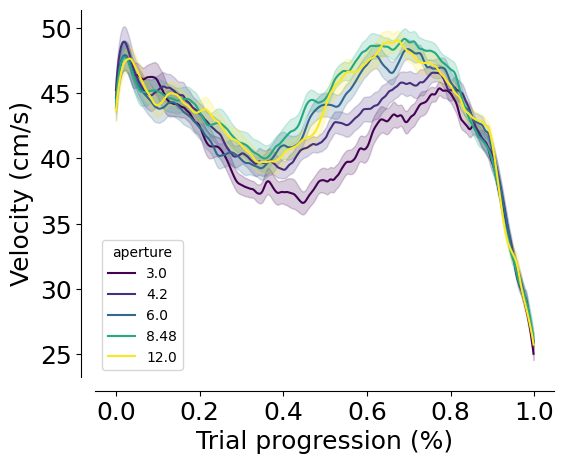

In [46]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ax = ax
mean_mouse = interpolated_j_shaped.groupby(
    ["dataset", "aperture", "trial_length"], as_index=False
).mean(numeric_only=True)

label = "velocity"
sns.lineplot(
        data=mean_mouse,
        x="trial_length",
        y="velocity",
        palette=
        "viridis",
        hue="aperture",
        errorbar="se",
        ax=ax,
    )
#ax.set_title(f"{label}")
sns.despine(offset=10)
ax.set_xlabel("Trial progression (%)")
ax.set_ylabel("Velocity (cm/s)")
plt.tight_layout(pad=2)
plt.savefig(save_fig_path + "multi_occluder_veloctiy.svg", transparent=False)



In [10]:
model_labels = [
    "x",
    "y",
    "velocity_x",
    "velocity_y",
    "heading_dir_sin",
    "heading_dir_cos",
    "head_angle_sin",
    "head_angle_cos",
    "trial_tortuosity",
    #"trial_duration",
    #"aperture",
    "trial_rewarded",
    "trial_length",
]

In [11]:
interpolated_j_shaped["aperture"] = interpolated_j_shaped["aperture"].astype(float)

df_model, coef = regression.predict_decision(
    df=interpolated_j_shaped, label=model_labels, per_mouse=True)

<Axes: xlabel='trial_length', ylabel='accuracy'>

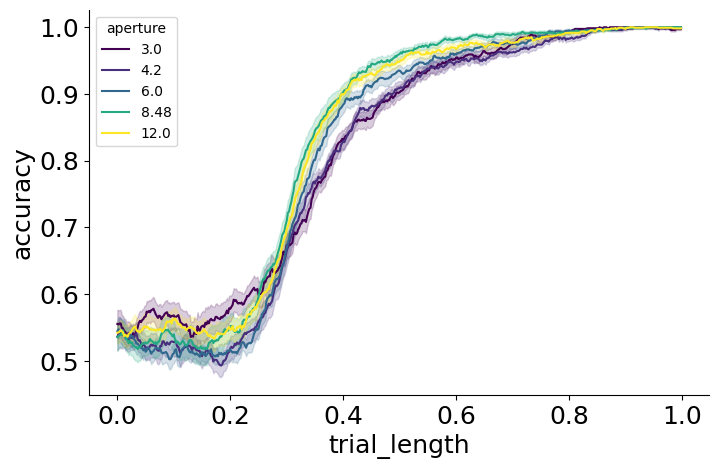

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

mean_mouse = df_model.groupby(["dataset", "aperture", "trial_length"]).mean(
    numeric_only=True
)

mean_mouse_per_choice = df_model.groupby(
    ["dataset", "trial_left_choice", "aperture", "trial_length"]
).mean(numeric_only=True)

# Accuracy
sns.lineplot(
    ax=ax,
    data=mean_mouse,
    y="accuracy",
    x="trial_length",
    hue="aperture",
    palette="viridis",
    errorbar="se",
)
sns.despine(offset=10)
ax.set_xlabel("Trial progression")
ax.set_ylabel("Accuracy")
#percentile = np.percentile(mean_mouse_model_shuff.accuracy, 95)
plt.savefig(save_fig_path + "multi_occluder_model_accuracy.svg", transparent=False)


In [13]:
df_model ["session"] = df_model ["dataset"]
df_model ["trial_L_choice"] = df_model ["trial_left_choice"]
decision_points = regression.find_decision_point(df_model, threshold_uncertainty=0.3)


2025-01-10 12:31:41,867::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-10 12:31:41,867::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-10 12:31:41,874::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-10 12:31:41,874::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-10 12:31:41,900::INFO::category.py::Using categorical un

3.0-4.2: TtestResult(statistic=4.072449065435792, pvalue=0.0005054599394518282, df=22)
3.0-6.0: TtestResult(statistic=5.324320080968275, pvalue=2.411026254833839e-05, df=22)
3.0-8.48: TtestResult(statistic=11.291230989371877, pvalue=1.268075148170175e-10, df=22)
4.2-6.0: TtestResult(statistic=3.4450950723936917, pvalue=0.0023086512977279045, df=22)
4.2-8.48: TtestResult(statistic=6.898066628106478, pvalue=6.300658507606434e-07, df=22)
6.0-8.48: TtestResult(statistic=3.6240410829430116, pvalue=0.0015018532994096132, df=22)
12.0-3.0: TtestResult(statistic=-11.22173398083199, pvalue=1.4248403767402893e-10, df=22)
12.0-4.2: TtestResult(statistic=-7.9294364592968885, pvalue=6.836425655155669e-08, df=22)
12.0-6.0: TtestResult(statistic=-5.898915803069249, pvalue=6.171873617617189e-06, df=22)
12.0-8.48: TtestResult(statistic=-1.4817443193947024, pvalue=0.15259079710455717, df=22)


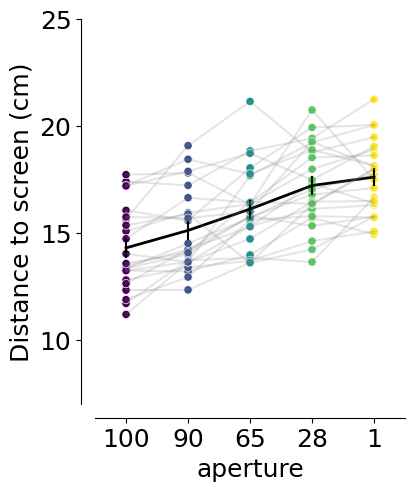

In [45]:
fig, ax = plt.subplots(1, 1, figsize=(4, 5))
stats = plotting.plot_decision_point(decision_points, label_parameter="y",  ax=ax, cmap=["#fde725", "#440154",  "#3b528b", "#21918c", "#5ec962"] )
ax.set_ylim(7,25)
ax.set_xlim(-.5,4.5)
ax.set_xticks([0,1,2,3,4], ["100", "90", "65", "28", "1"])
sns.despine(offset=10)
plt.savefig(save_fig_path + "multi_occlulder_decision_points.svg", transparent=True)

dict_values([0.0005054599394518282, 2.411026254833839e-05, 1.268075148170175e-10, 0.0023086512977279045, 6.300658507606434e-07, 0.0015018532994096132, 1.4248403767402893e-10, 6.836425655155669e-08, 6.171873617617189e-06, 0.15259079710455717])

In [22]:
decision_points = decision_points.groupby(["dataset", "aperture"], as_index=False).mean()
anova_rm = AnovaRM(decision_points, depvar='y', subject='dataset', within=['aperture'])
anova_results = anova_rm.fit()

# Print the ANOVA table
print(anova_results)

# If you want to save the results to a variable and explore it further
anova_table = anova_results.summary()

# Display the summary table
print(anova_table)

                Anova
         F Value Num DF  Den DF Pr > F
--------------------------------------
aperture 47.5261 4.0000 88.0000 0.0000

                Anova
         F Value Num DF  Den DF Pr > F
--------------------------------------
aperture 47.5261 4.0000 88.0000 0.0000



In [23]:
stats.values()

dict_values([0.0005054599394518282, 2.411026254833839e-05, 1.268075148170175e-10, 0.0023086512977279045, 6.300658507606434e-07, 0.0015018532994096132, 1.4248403767402893e-10, 6.836425655155669e-08, 6.171873617617189e-06, 0.15259079710455717])

In [24]:
from statsmodels.stats.multitest import multipletests

In [36]:
mt = multipletests(list(stats.values()), method="bonferroni")

In [39]:
corr_p = pd.DataFrame({"comparison": stats.keys(), "uncorr_p": list(stats.values()), "corr_p": mt[1], "sig": mt[0]}) #stats)

In [40]:
corr_p

,comparison,uncorr_p,corr_p,sig
0,3.0-4.2,5.054599e-04,5.054599e-03,True
1,3.0-6.0,2.411026e-05,2.411026e-04,True
2,3.0-8.48,1.268075e-10,1.268075e-09,True
3,4.2-6.0,2.308651e-03,2.308651e-02,True
4,4.2-8.48,6.300659e-07,6.300659e-06,True
5,6.0-8.48,1.501853e-03,1.501853e-02,True
6,12.0-3.0,1.424840e-10,1.424840e-09,True
7,12.0-4.2,6.836426e-08,6.836426e-07,True
8,12.0-6.0,6.171874e-06,6.171874e-05,True
9,12.0-8.48,1.525908e-01,1.000000e+00,False


In [81]:
trials_by_time = interpolated_j_shaped.groupby(["aperture", "trial_step", "trial_left_choice"], as_index=False)[["x", "y"]].mean()

<Axes: xlabel='y', ylabel='x'>

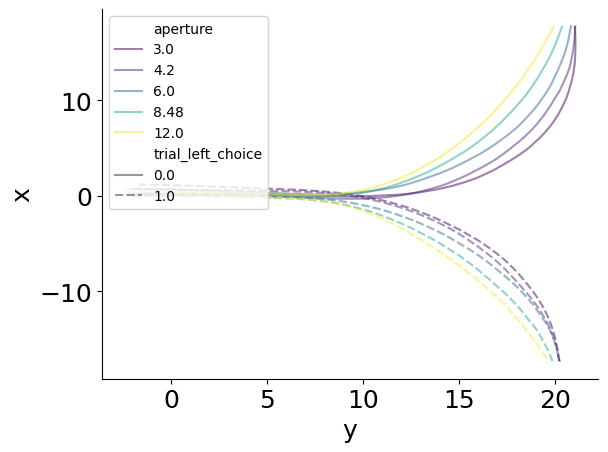

In [83]:
sns.lineplot(trials_by_time, x="y", y="x", hue="aperture", style = "trial_left_choice", palette ="viridis", sort=False, alpha=0.5)

In [57]:
interpolated_j_shaped.keys()

Index(['time', 'trial_left_choice', 'norm_y', 'norm_x', 'heading_dir',
       'head_angle', 'trial_tortuosity', 'trial_duration', 'x', 'y',
       'aperture', 'velocity', 'velocity_x', 'velocity_y', 'trial_rewarded',
       'flip_one_side', 'dataset', 'trial', 'trial_step', 'trial_length',
       'head_angle_sin', 'head_angle_cos', 'heading_dir_sin',
       'heading_dir_cos', 'velocity_x_fliped'],
      dtype='object')